In [1]:
import pandas as pd
import numpy as np

# Carga
df = pd.read_csv("../../data/processed/weather_processed.csv")

X = df.drop(columns=["Rain"])
y = df["Rain"]

print(X.columns.tolist())

['TMAX', 'TMIN', 'ADPT', 'ASLP', 'ASTP', 'AWBT', 'AWND', 'RHAV', 'RHMN', 'RHMX', 'WDF2', 'WDF5', 'WSF2', 'WSF5', 'month', 'dayofweek', 'month_sin', 'month_cos']


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [35]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression

pipeline_log = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [25]:
param_log = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],  # seguro
    "model__solver": ["lbfgs", "liblinear", "sag"]
}

In [36]:
search_log = RandomizedSearchCV(
    pipeline_log,
    param_distributions=param_log,
    n_iter=10,
    scoring="roc_auc",
    cv= cv,
    random_state=42,
    n_jobs=-1
)

In [27]:
from sklearn.svm import SVC

pipeline_svm = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True))
])

In [28]:
param_svm = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.1, 0.01, 0.001],
    "model__kernel": ["linear", "rbf"]
}

In [37]:
search_svm = RandomizedSearchCV(
    pipeline_svm,
    param_distributions=param_svm,
    n_iter=10,
    scoring="roc_auc",
    cv= cv,
    random_state=42,
    n_jobs=-1
)

In [30]:
from xgboost import XGBClassifier

pipeline_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

In [31]:
param_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

In [38]:
search_xgb = RandomizedSearchCV(
    pipeline_xgb,
    param_distributions=param_xgb,
    n_iter=15,  # un poco más porque tiene más params
    scoring="roc_auc",
    cv= cv,
    random_state=42,
    n_jobs=-1
)

In [39]:
search_log.fit(X_train, y_train)
search_svm.fit(X_train, y_train)
search_xgb.fit(X_train, y_train)

print("Logistic Best:")
print(search_log.best_score_)
print(search_log.best_params_)
print()

print("SVM Best:")
print(search_svm.best_score_)
print(search_svm.best_params_)
print()

print("XGBoost Best:")
print(search_xgb.best_score_)
print(search_xgb.best_params_)

Logistic Best:
0.8732055659965916
{'model__solver': 'sag', 'model__penalty': 'l2', 'model__C': 100}

SVM Best:
0.8772448404448173
{'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__C': 100}

XGBoost Best:
0.8722118504687957
{'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


In [40]:
best_svm = search_svm.best_estimator_
y_pred = best_svm.predict(X_test)
y_proba = best_svm.predict_proba(X_test)[:, 1]

In [48]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

metrics

,Metric,Score
0,Accuracy,0.799544
1,Precision,0.756345
2,Recall,0.788360
3,F1-score,0.772021


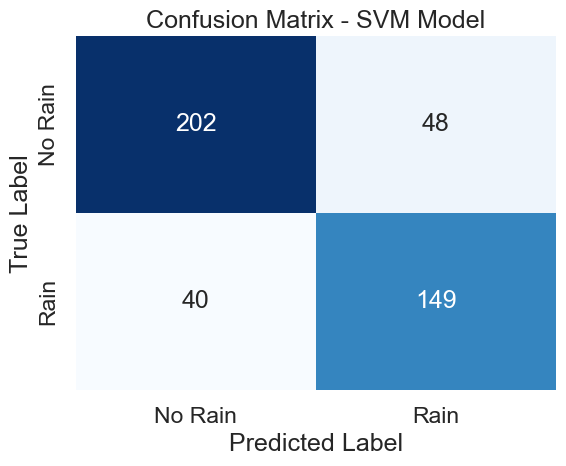

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Model")
plt.tight_layout()
plt.show()

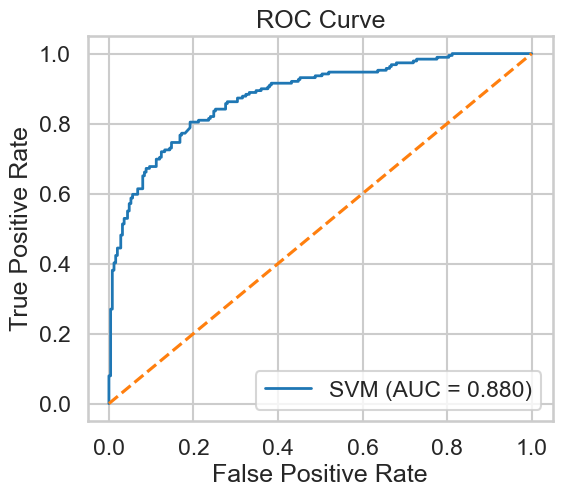

In [62]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f"SVM (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()